Text(0.5, 1.0, 'Classes Data')

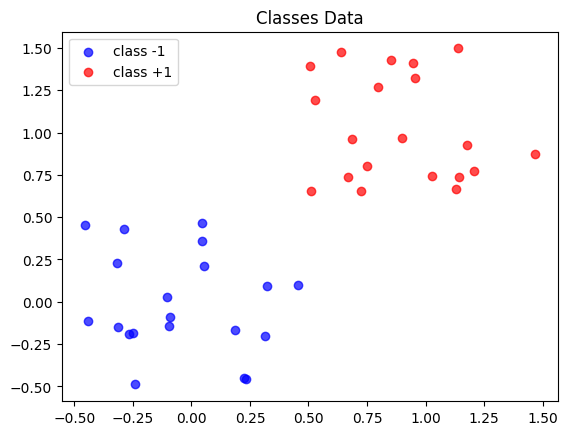

In [37]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(67)

x_neg = np.random.rand(20,2) - 0.5
x_pos = np.random.rand(20,2) + 0.5

X = np.vstack([x_neg,x_pos])
Y = np.array([-1]*20+[1]*20)

plt.scatter(X[Y==-1,0],X[Y==-1,1],label='class -1',color='blue',alpha=0.7)
plt.scatter(X[Y==1,0],X[Y==1,1],label='class +1',color='red',alpha=0.7)
plt.legend()
plt.title("Classes Data")

(40,) (2,) (40, 2)
epoch = 0: loss = 32.2133
epoch = 50: loss = 4.8715
epoch = 100: loss = 4.7783
epoch = 150: loss = 4.7554
epoch = 200: loss = 4.7398
epoch = 250: loss = 4.7304
epoch = 300: loss = 4.7245
epoch = 350: loss = 4.7205
epoch = 400: loss = 4.7273
epoch = 450: loss = 4.7206


Text(0.5, 1.0, 'Classes Data')

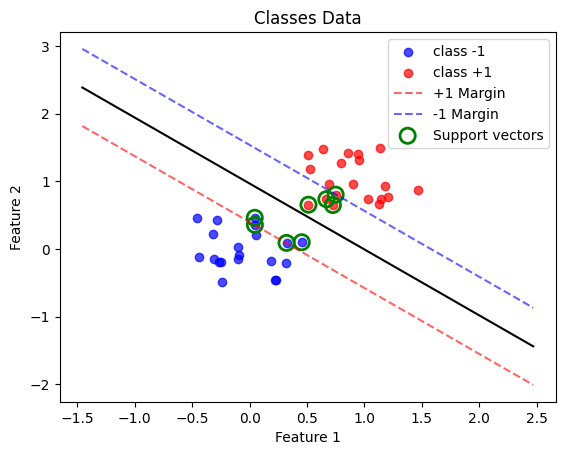

In [38]:
def geometric_margin(x,y,w,b):
    return y*(x@w +b)/np.linalg.norm(w)

def hinge_loss(x,y,w,b,c=1.0):
    margins = y * (x @ w + b)
    loss    = np.maximum(0, 1 - margins)       
    return (1/2) * np.dot(w, w) + c * np.sum(loss)

def gradient(x,y,w,b,c=1.0):
    margin = y*(x@w+b)
    mask = (margin < 1).astype(float)
    dw = w - c*(y*mask)@ x
    db = -c*np.sum(y*mask)

    return dw,db


def train_svm(x,y,c=1.0,rate=0.1,epochs=500):
    m,n = x.shape
    w = np.zeros(n)
    b = 0
    hist = []
    print(y.shape,w.shape,x.shape)
    for e in range(epochs):
        dw,db =  gradient(x,y,w,b,c)

        w -= rate*dw
        b -= rate*db

        loss = hinge_loss(x=x,y=y,w=w,b=b,c=c)

        hist.append(loss)

        if len(hist) > 1 and abs(hist[-2] - hist[-1]) < 1e-6:
            print(f"Converged at epoch {e}")
            break

        if e%50==0:
            print(f"epoch = {e}: loss = {loss:.4f}")
    
    return w,b,hist

w,b,hist = train_svm(X,Y,c=1.0,rate=0.01,epochs=500)

plt.scatter(X[Y==-1,0],X[Y==-1,1],label='class -1',color='blue',alpha=0.7)
plt.scatter(X[Y==1,0],X[Y==1,1],label='class +1',color='red',alpha=0.7)

x1_range = np.linspace(X[:,0].min()-1,X[:,0].max()+1,100)

def get_x2(x1,w,b,offset=0):
    return -(w[0]*x1+b+offset)/w[1]

x2_bound = get_x2(x1_range,w,b,offset=0)
x2_upper_margin = get_x2(x1_range,w,b,offset=1)
x2_lower_margin = get_x2(x1_range,w,b,offset=-1)


plt.plot(x1_range,x2_bound,'k-')
plt.plot(x1_range,x2_upper_margin,"r--",alpha=0.6,label='+1 Margin')
plt.plot(x1_range,x2_lower_margin,"b--",alpha=0.6,label='-1 Margin')


margins = Y * (X @ w + b)
support_vectors = X[margins <= 1.05]  
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            s=120, facecolors='none', edgecolors='green',
            linewidths=2, label='Support vectors')

plt.title("SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.title("Classes Data")


In [39]:

def kernel_linear(x1, x2):
    return np.dot(x1, x2)


def kernel_rbf(x1, x2, gamma=0.5):
    diff = x1 - x2
    return np.exp(-gamma * np.dot(diff, diff))


def kernel_poly(x1, x2, degree=2, c=1):
    return (np.dot(x1, x2) + c) ** degree

def compute_kernel_matrix(X, kernel_fn, **kwargs):
    m = len(X)
    K = np.zeros((m, m))

    for i in range(m):
        for j in range(m):
            K[i, j] = kernel_fn(X[i], X[j], **kwargs)

    return K    

K = compute_kernel_matrix(X, kernel_rbf, gamma=0.5)

print("Kernel matrix shape:", K.shape)     
m= X.shape[0]
print(m)

Kernel matrix shape: (40, 40)
40


Gamma= 0.01  avg cross-class similarity = 0.9776
Gamma=  0.1  avg cross-class similarity = 0.8011
Gamma=  0.5  avg cross-class similarity = 0.3649


Gamma=  2.0  avg cross-class similarity = 0.0504
Gamma= 10.0  avg cross-class similarity = 0.0008
Margin width: 0.8166
Min geometric margin: 0.1337


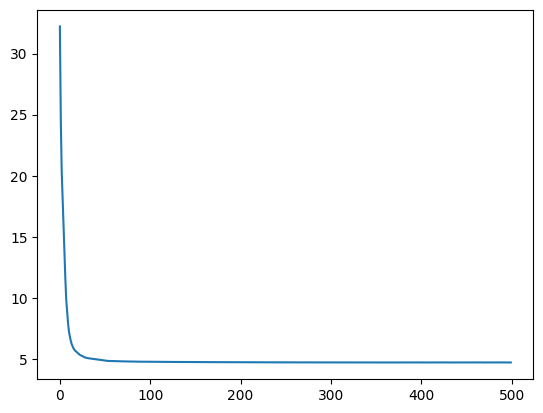

In [ ]:
gammas = [0.01, 0.1, 0.5, 2.0, 10.0]

for gamma in gammas:
    K = compute_kernel_matrix(X, kernel_rbf, gamma=gamma)
    avg_similarity = K[Y==1][:, Y==-1].mean() 
    print(f"Gamma={gamma:>5}  avg cross-class similarity = {avg_similarity:.4f}")


margins = geometric_margin(X, Y, w, b)
print(f"Margin width: {2/np.linalg.norm(w):.4f}")
print(f"Min geometric margin: {margins.min():.4f}")

plt.plot(hist)